In [5]:
# Import settings
nb_settings_path = "./settings.py"
with open(nb_settings_path) as f:
    code = f.read()
    exec(code)

In [6]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import seaborn as sns
import itertools
from pathlib import Path
from utils import N_palette, D_palette, Ns, Ds, N_color_map, D_color_map, FORMAT_N, FORMAT_D, N_ticks, D_ticks, N_to_N_approx, N_approx_to_N

In [7]:
N_1_7B = N_approx_to_N[1.7e9]

In [8]:
def plot_scaling_law_bootstrap(law_fn, log_params_bootstrap, title, df_train, df_test, ylim=None, log_preds=False, ci=False, save_path=None):

    D_min = min(df_train["D"].min(), df_test["D"].min())
    D_max = max(df_train["D"].max(), df_test["D"].max())
    D_grid = np.logspace(np.log10(D_min), np.log10(D_max), 200)
    D_grid_1_7B = np.logspace(np.log10(20e9), np.log10(300e9), 200)

    fig, ax = plt.subplots(figsize=(6, 4))
    # fig, ax = plt.subplots(figsize=(8, 5))

    sns.scatterplot(data=df_train, x="D", y=loss_key, hue="N", palette=N_color_map, edgecolor="black", linewidth=0.75, s=50, legend=False, ax=ax)
    sns.scatterplot(data=df_test, x="D", y=loss_key, hue="N", palette=N_color_map, marker="*", edgecolor="black", linewidth=0.75, s=60, legend=False, ax=ax)

    Ns = sorted(df_train["N"].unique())

    for N in Ns:
        y_pred_boot = np.array([law_fn((np.log(N), np.log(D_grid)), *p) for p in log_params_bootstrap])
        if log_preds:
            y_pred_boot = np.exp(y_pred_boot)

        y_mean = np.mean(y_pred_boot, axis=0)
        y_lo, y_hi = np.percentile(y_pred_boot, [2.5, 97.5], axis=0)

        if ci:
            ax.fill_between(D_grid, y_lo, y_hi, color=N_color_map[N], alpha=0.15, linewidth=0)
        ax.plot(D_grid, y_mean, color=N_color_map[N], linewidth=1.25)

    y_pred_boot_1_7B = np.array([law_fn((np.log(np.full_like(D_grid_1_7B, N_1_7B)), np.log(D_grid_1_7B)), *p) for p in log_params_bootstrap])
    if log_preds:
        y_pred_boot_1_7B = np.exp(y_pred_boot_1_7B)

    y_mean_1_7B = np.mean(y_pred_boot_1_7B, axis=0)
    y_lo_1_7B, y_hi_1_7B = np.percentile(y_pred_boot_1_7B, [2.5, 97.5], axis=0)

    if ci:
        ax.fill_between(D_grid_1_7B, y_lo_1_7B, y_hi_1_7B, color=N_color_map[N_1_7B], alpha=0.15, linewidth=0)
    ax.plot(D_grid_1_7B, y_mean_1_7B, color=N_color_map[N_1_7B], linewidth=1.5, linestyle="--")

    ax.set_ylim(ylim)
    ax.set_xscale("log")
    ax.set_xlabel(r"$D$", fontsize=13)
    ax.set_ylabel(r"Validation Loss $\downarrow$", fontsize=13)
    ax.tick_params(axis="both", labelsize=11)
    ax.set_xticks(D_ticks)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: FORMAT_D(x)))
    ax.set_title(title, fontsize=13)

    Ns_all = sorted(set(df_train["N"]).union(df_test["N"]))
    color_handles = [
        Line2D([0], [0], marker="*" if N == N_1_7B else "o", linestyle="None", 
               markersize=8 if N == N_1_7B else 6, markerfacecolor=N_color_map[N], 
               markeredgecolor="black" if N == N_1_7B else N_color_map[N], label=FORMAT_N(N)) 
        for N in Ns_all
    ]

    color_legend = ax.legend(handles=color_handles, title=r"$N$", loc="upper right", ncols=3, fontsize=9.75, title_fontsize=9.75)
    ax.add_artist(color_legend)

    style_legend = [
        Line2D([0], [0], marker="o", linestyle="None", markersize=6, color="black", 
               label="Train set"), Line2D([0], [0], marker="*", linestyle="None", markersize=6, color="black", label="Test set"), 
        Line2D([0], [0], linestyle="-", linewidth=1.5, color="black", label="Bootstrap mean"), Line2D([0], [0], linestyle="--", linewidth=1.5, color="black", label="Bootstrap prediction"), Patch(facecolor="black", alpha=0.15, label="95\% bootstrap CI")]

    ax.legend(handles=style_legend, loc="lower left", fontsize=9)

    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=400)

    plt.show()

    return fig, ax

# Data

In [9]:
loss_key = 'loss'

# Optimal (lr, gbsz) for each (N, D)
df_best_lr_gbsz = pd.read_csv('../data//best_HPs/lr_gbsz_min.csv')
df_best_lr_gbsz.head(5)

,job_name,N,N_approx,D,C,lr,gbsz,beta2,seed,iteration,train_samples,train_tokens,num_of_valid_seq,loss,loss_se
0,dense_50M_xm01_lr0.002_gbsz32_beta20.99_6B,47557632,50000000.0,6.000000e+09,1.712075e+18,0.002,32,0.99,1234,45777.0,1464864.0,6.000083e+09,204800.0,2.927179,0.002212
1,dense_50M_xm01_lr0.002_gbsz64_beta20.99_12B,47557632,50000000.0,1.200000e+10,3.424150e+18,0.002,64,0.99,1234,45777.0,2929728.0,1.200017e+10,204800.0,2.874713,0.000000
2,dense_50M_xm01_lr0.002_gbsz64_beta20.99_20B,47557632,50000000.0,2.000000e+10,5.706916e+18,0.002,64,0.99,1234,76294.0,4882816.0,2.000001e+10,204800.0,2.841727,0.000000
3,dense_50M_xm01_lr0.002_gbsz64_beta20.99_30B,47557632,50000000.0,3.000000e+10,8.560374e+18,0.002,64,0.99,1234,114441.0,7324224.0,3.000002e+10,204800.0,2.819773,0.000000
4,dense_50M_xm01_lr0.004_gbsz256_beta20.99_50B,47557632,50000000.0,5.000000e+10,1.426729e+19,0.004,256,0.99,1234,47684.0,12207104.0,5.000030e+10,204800.0,2.797380,0.001047


# Chinchilla

In [13]:
# Load Bootstrap resultls
chinchilla_boot = np.load("../data/bootstrap/bootstrap_chinchilla.npz")
log_params_chinchilla_boot = chinchilla_boot["params_bootstrap"]
huber_chinchilla_boot = chinchilla_boot["objective_bootstrap"]
seeds_chinchilla_boot = chinchilla_boot["seeds"]

n_boot = len(log_params_chinchilla_boot)
print(n_boot)
print(log_params_chinchilla_boot.shape)

1000
(1000, 5)


In [14]:
# Convert every bootstrap replicate back to original parameterization
log_E, log_A, alpha, log_B, beta = log_params_chinchilla_boot.T
params_chinchilla_boot = np.column_stack([np.exp(log_E), np.exp(log_A), alpha, np.exp(log_B), beta])


# Mean, standard error, and 95% bootstrap percentile CI
param_names = ["E", "A", "alpha", "B", "beta"]
param_mean = params_chinchilla_boot.mean(axis=0)
param_se = params_chinchilla_boot.std(axis=0, ddof=1)
param_ci = np.percentile(params_chinchilla_boot, [2.5, 97.5], axis=0)

for name, mean, se, lo, hi in zip(param_names, param_mean, param_se, param_ci[0], param_ci[1]):
    print(f"{name}: \t {mean:.6g} ± {se:.6g} \t [{lo:.6g}, {hi:.6g}]")

E: 	 1.41835 ± 0.250872 	 [0.850804, 1.76577]
A: 	 208.477 ± 209.157 	 [40.4368, 735.713]
alpha: 	 0.280688 ± 0.0496421 	 [0.194151, 0.380843]
B: 	 528.719 ± 1286.71 	 [6.94101, 3934.65]
beta: 	 0.253367 ± 0.0805872 	 [0.0895997, 0.413712]


In [15]:
def scaling_law_chinchilla(X, log_E, log_A, alpha, log_B, beta):
    log_N, log_D = X

    E = np.exp(log_E)
    A = np.exp(log_A)
    B = np.exp(log_B)

    # return E + A * N**(-alpha) + B * D**(-beta)
    return (
        E
        + A * np.exp(-alpha * log_N)
        + B * np.exp(-beta * log_D)
    )

In [16]:
# --- Reserve held-out set and fit ---
df_base = df_best_lr_gbsz.copy()

# Held out set: 1.7B
df_train = df_base[df_base.N_approx < 1.7e9].copy()
df_test = df_base[df_base.N_approx == 1.7e9].copy()

df_fit = df_train.copy()

# Check
df_fit.N.unique()

array([ 47557632, 124455168, 301880320, 588544000, 983138304])

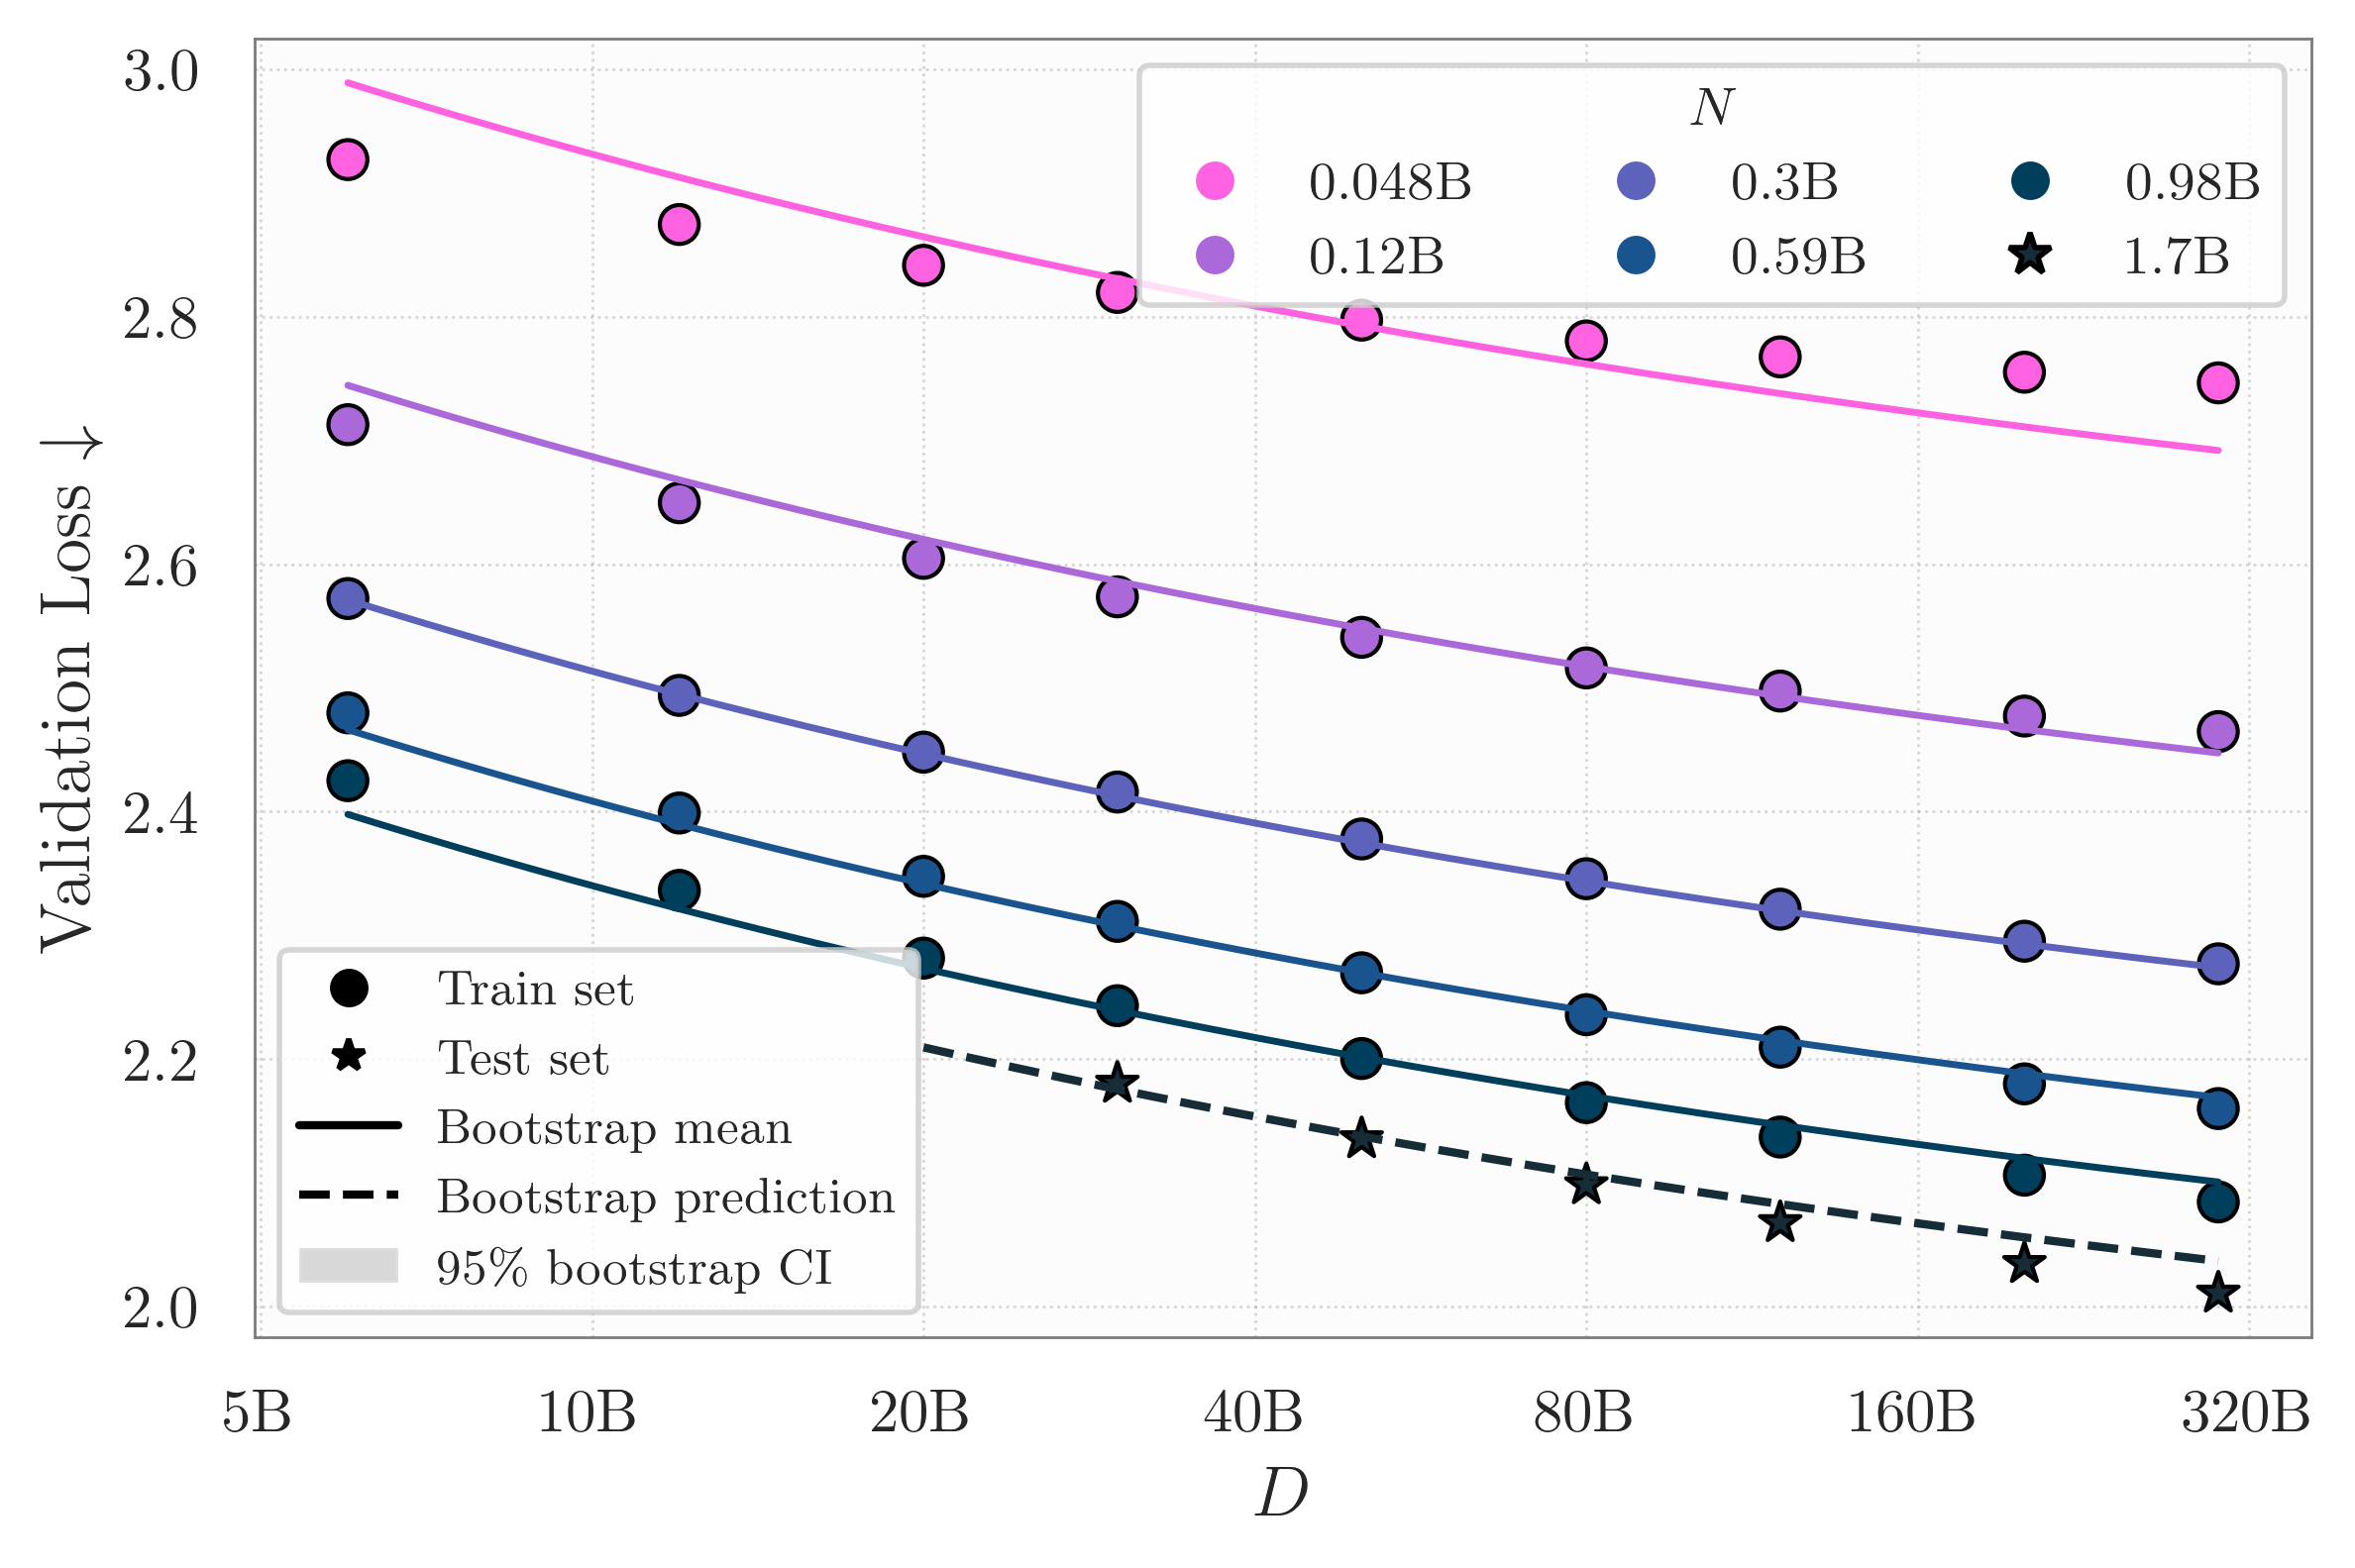

(<Figure size 2400x1600 with 1 Axes>,
 <Axes: xlabel='$D$', ylabel='Validation Loss $\\downarrow$'>)

In [17]:
plot_scaling_law_bootstrap(
    scaling_law_chinchilla, 
    log_params_chinchilla_boot, 
    None,
    df_train, 
    df_test,
    save_path="../fig/loss_scaling/chinchilla.pdf",
    ylim=[1.975, 3.025],
)

# Skaling

In [18]:
# Load Skaling resultls
skaling_boot = np.load("../data/bootstrap/bootstrap_skalling.npz")
log_params_skaling_boot = skaling_boot["params_bootstrap"]
huber_skaling_boot = skaling_boot["objective_bootstrap"]
seeds_skaling_boot = skaling_boot["seeds"]

n_boot = len(log_params_skaling_boot)
print(n_boot)
print(log_params_skaling_boot.shape)

1000
(1000, 6)


In [19]:
# Convert every bootstrap replicate back to original parameterization
log_E, log_A, alpha, log_B, beta, k = log_params_skaling_boot.T
params_skaling_boot = np.column_stack([np.exp(log_E), np.exp(log_A), alpha, np.exp(log_B), beta, k])


# Mean, standard error, and 95% bootstrap percentile CI
param_names = ["E", "A", "alpha", "B", "beta", "k"]
param_mean = params_skaling_boot.mean(axis=0)
param_se = params_skaling_boot.std(axis=0, ddof=1)
param_ci = np.percentile(params_skaling_boot, [2.5, 97.5], axis=0)

for name, mean, se, lo, hi in zip(param_names, param_mean, param_se, param_ci[0], param_ci[1]):
    print(f"{name}: \t {mean:.6g} ± {se:.6g} \t [{lo:.6g}, {hi:.6g}]")

E: 	 1.03013 ± 0.0873461 	 [0.850241, 1.202]
A: 	 23434 ± 14108.1 	 [4986.95, 56151.9]
alpha: 	 0.49103 ± 0.0301953 	 [0.42832, 0.548543]
B: 	 4629.59 ± 2942.97 	 [1649.99, 13867.9]
beta: 	 0.349563 ± 0.0215646 	 [0.313467, 0.405134]
k: 	 0.410509 ± 0.0326706 	 [0.359382, 0.479076]


In [20]:
def scaling_law_skaling(X, log_E, log_A, alpha, log_B, beta, k):
    log_N, log_D = X

    E = np.exp(log_E)
    A = np.exp(log_A)
    B = np.exp(log_B)

    return E + (
        A * np.exp(-alpha * log_N) + B * np.exp(-beta * log_D)
    ) ** k

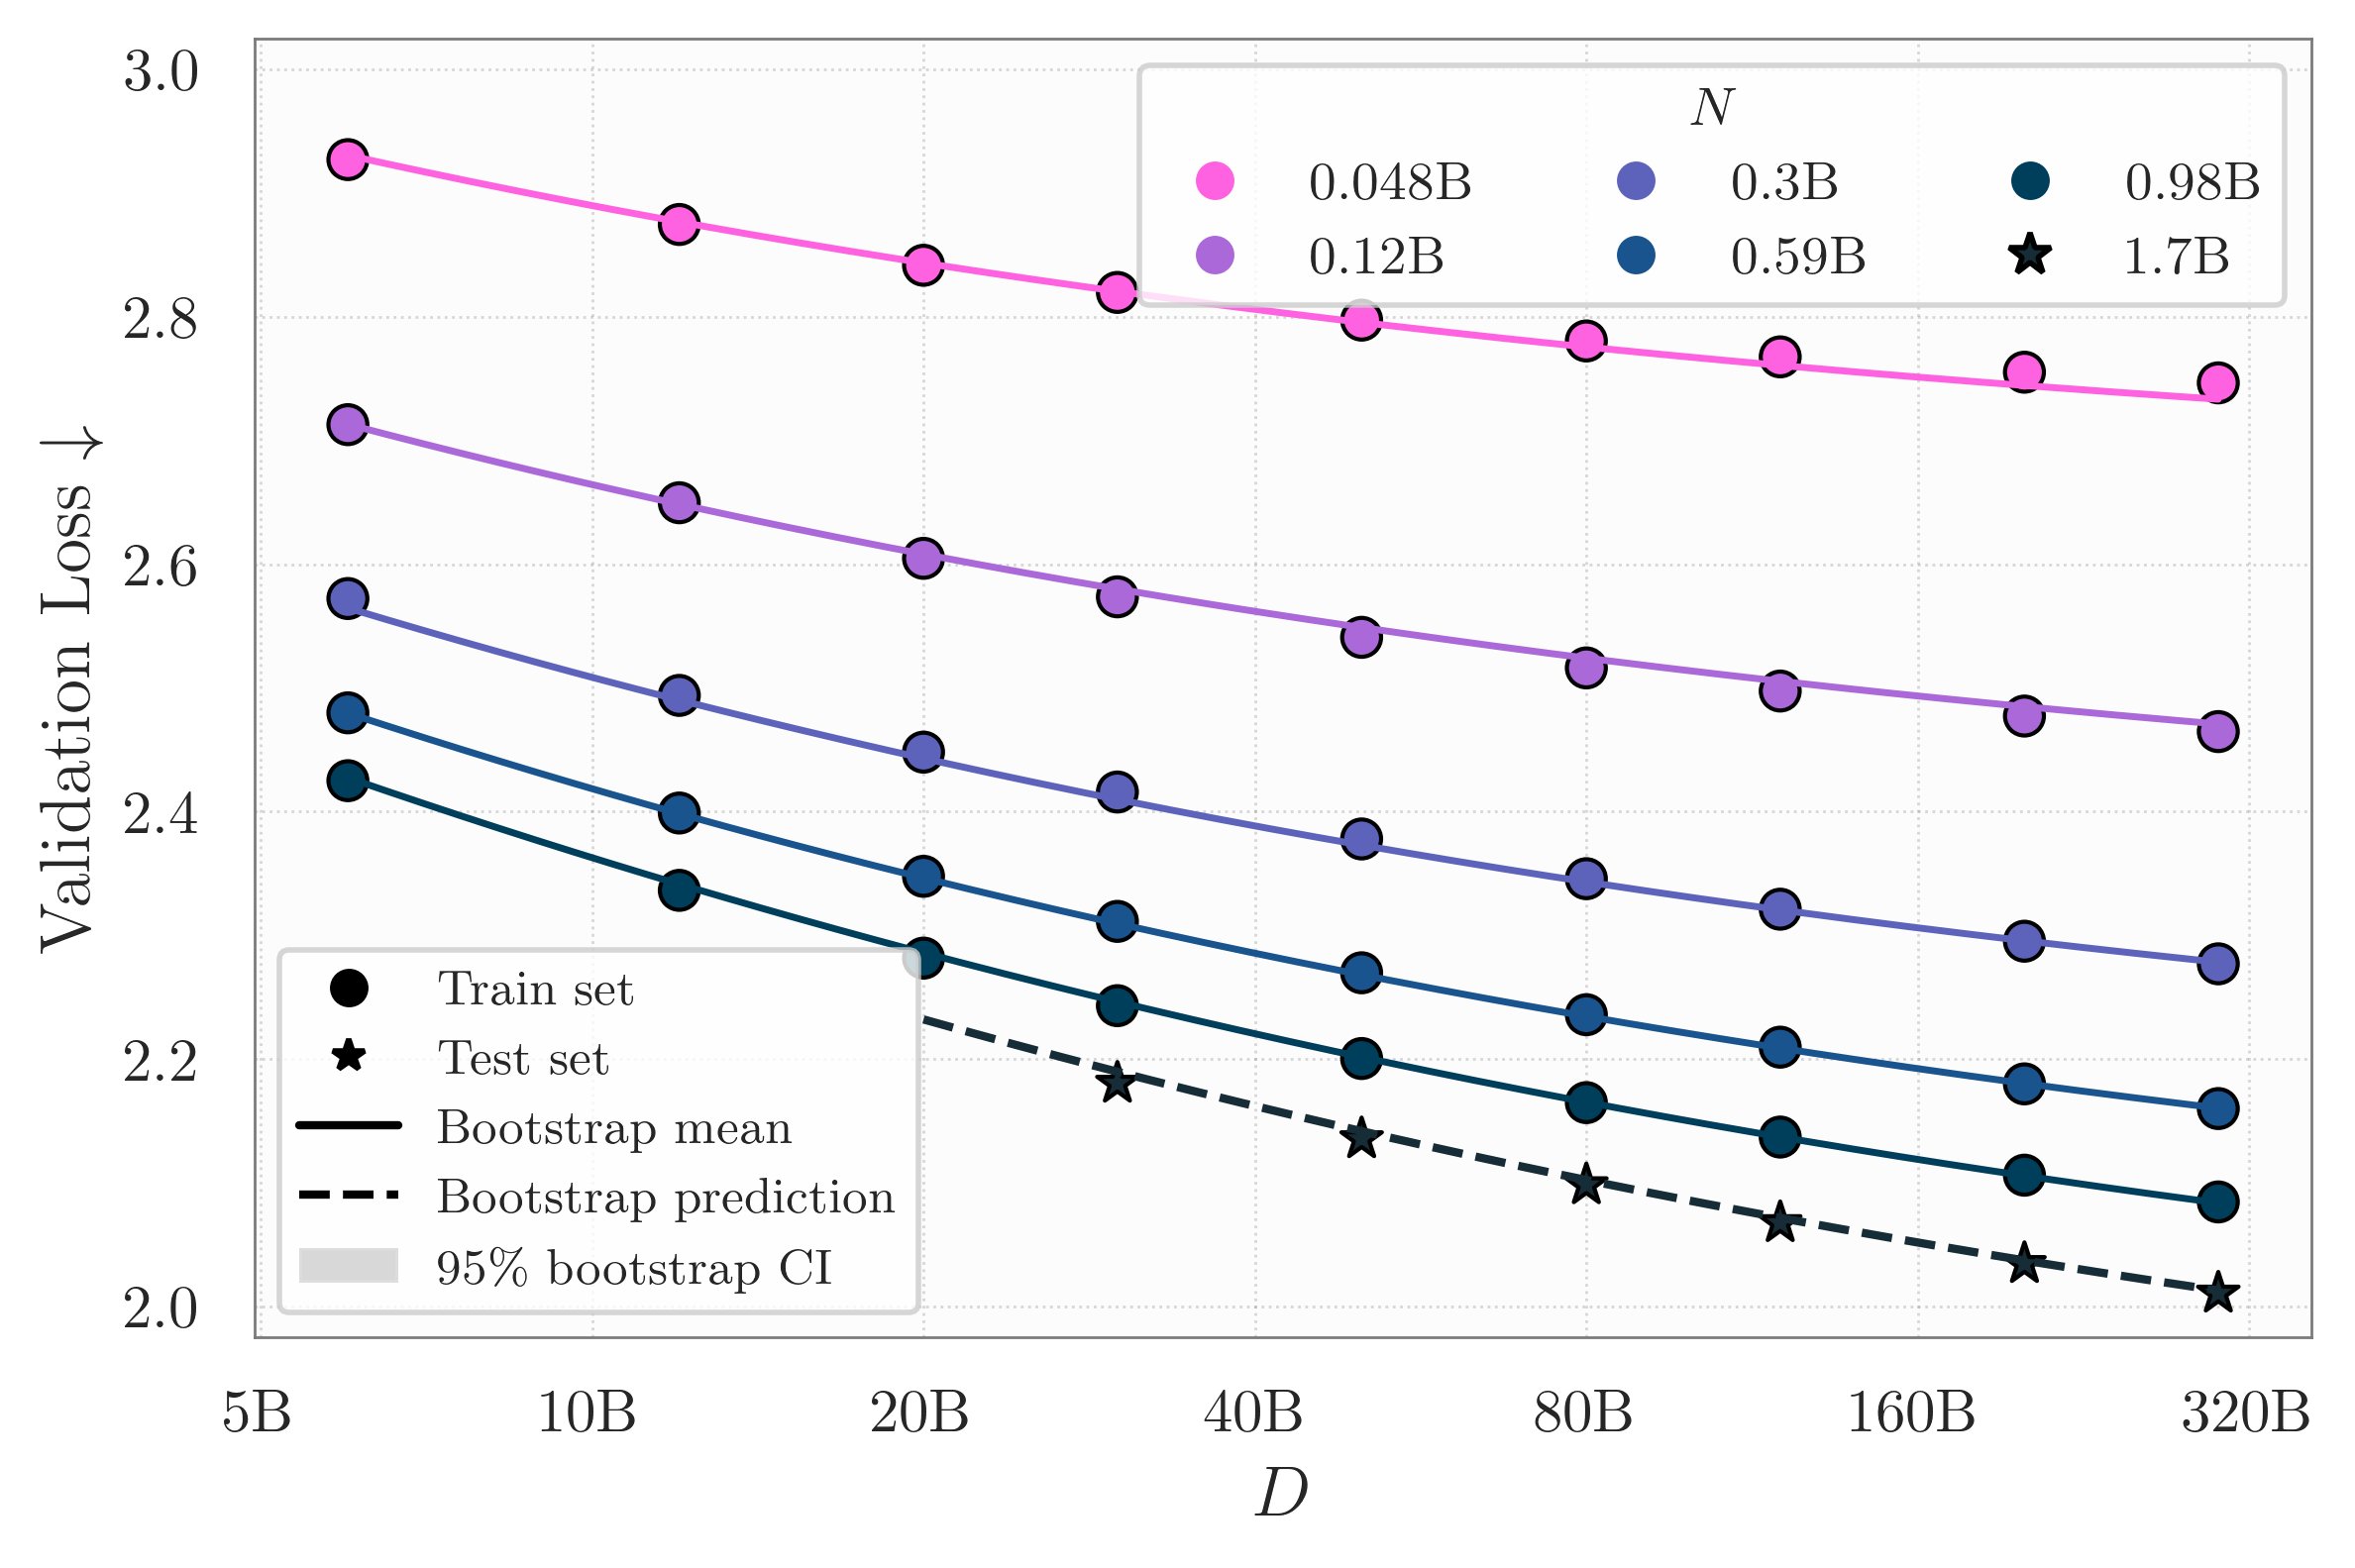

(<Figure size 2400x1600 with 1 Axes>,
 <Axes: xlabel='$D$', ylabel='Validation Loss $\\downarrow$'>)

In [21]:
plot_scaling_law_bootstrap(
    scaling_law_skaling, 
    log_params_skaling_boot, 
    None, 
    df_train, 
    df_test,
    save_path="../fig/loss_scaling/skaling.pdf",
    ylim=[1.975, 3.025],
)

# LaTex

In [22]:
import numpy as np
from sklearn.metrics import root_mean_squared_error


# ============================================================
# Bootstrap means + standard errors
# ============================================================

chinchilla_mean = params_chinchilla_boot.mean(axis=0)
chinchilla_se = params_chinchilla_boot.std(axis=0, ddof=1)

skaling_mean = params_skaling_boot.mean(axis=0)
skaling_se = params_skaling_boot.std(axis=0, ddof=1)


# ============================================================
# Huber loss
# ============================================================

huber_chinchilla_mean = huber_chinchilla_boot.mean()
huber_skaling_mean = huber_skaling_boot.mean()


# ============================================================
# Held-out RMSE
# ============================================================

y_test = df_test[loss_key].to_numpy()
N_test = df_test["N"].to_numpy()
D_test = df_test["D"].to_numpy()


rmse_chinchilla_boot = np.array([
    root_mean_squared_error(
        y_test,
        scaling_law_chinchilla((N_test, D_test), *p)
    )
    for p in log_params_chinchilla_boot
])

rmse_skaling_boot = np.array([
    root_mean_squared_error(
        y_test,
        scaling_law_skaling((N_test, D_test), *p)
    )
    for p in log_params_skaling_boot
])


rmse_chinchilla_mean = rmse_chinchilla_boot.mean()
rmse_skaling_mean = rmse_skaling_boot.mean()


# ============================================================
# LaTeX formatting
# ============================================================

def fmt_pm(mean, se):
    return (
        rf"\begin{{tabular}}{{@{{}}c@{{}}}}"
        rf"{mean:.6g}\\"
        rf"\scriptsize$\pm$ {se:.2g}"
        rf"\end{{tabular}}"
    )


# ============================================================
# Generate LaTeX table
# ============================================================
def fmt_pm(mean, se):
    return rf"$\substack{{{mean:.6g}\\[-2pt]\scriptsize \pm {se:.2g}}}$"

import numpy as np
from sklearn.metrics import root_mean_squared_error


# ============================================================
# Bootstrap means + standard errors
# ============================================================

chinchilla_mean = params_chinchilla_boot.mean(axis=0)
chinchilla_se = params_chinchilla_boot.std(axis=0, ddof=1)

skaling_mean = params_skaling_boot.mean(axis=0)
skaling_se = params_skaling_boot.std(axis=0, ddof=1)

# ============================================================
# Training Huber loss
# ============================================================

huber_chinchilla_mean = huber_chinchilla_boot.mean()
huber_skaling_mean = huber_skaling_boot.mean()

# ============================================================
# Held-out RMSE
# ============================================================

y_test = df_test[loss_key].to_numpy()
N_test = df_test["N"].to_numpy()
D_test = df_test["D"].to_numpy()
log_N_test = np.log(df_test["N"].to_numpy())
log_D_test = np.log(df_test["D"].to_numpy())

rmse_chinchilla_boot = np.array([
    root_mean_squared_error(
        y_test,
        scaling_law_chinchilla((log_N_test, log_D_test), *p)
    )
    for p in log_params_chinchilla_boot
])

rmse_skaling_boot = np.array([
    root_mean_squared_error(
        y_test,
        scaling_law_skaling((log_N_test, log_D_test), *p)
    )
    for p in log_params_skaling_boot
])

rmse_chinchilla_mean = rmse_chinchilla_boot.mean()
rmse_skaling_mean = rmse_skaling_boot.mean()


# ============================================================
# LaTeX table
# ============================================================

def fmt_pm(mean, se):
    return (
        rf"\begin{{tabular}}[t]{{@{{}}r@{{}}}}"
        rf"{mean:.4g}\\[-4pt]"
        rf"\scriptsize $\pm$ {se:.2g}"
        rf"\end{{tabular}}"
    )
    
latex = rf"""
\begin{{table}}[h]
    \centering
    \begin{{tabular}}{{lrrrrrrrr}}
    \toprule
    Model
        & $E$
        & $A$
        & $\alpha$
        & $B$
        & $\beta$
        & $k$
        & $\text{{Huber}}$
        & $\text{{RMSE}}_{{\text{{held-out}}}}$ \\
    \midrule
    Chinchilla (\ref{{eq:chinchilla}})
        & {fmt_pm(chinchilla_mean[0], chinchilla_se[0])}
        & {fmt_pm(chinchilla_mean[1], chinchilla_se[1])}
        & {fmt_pm(chinchilla_mean[2], chinchilla_se[2])}
        & {fmt_pm(chinchilla_mean[3], chinchilla_se[3])}
        & {fmt_pm(chinchilla_mean[4], chinchilla_se[4])}
        &
        & {huber_chinchilla_mean:.2e}
        & {rmse_chinchilla_mean:.3g}
        \\
    Skaling (\ref{{eq:skaling}})
        & {fmt_pm(skaling_mean[0], skaling_se[0])}
        & {fmt_pm(skaling_mean[1], skaling_se[1])}
        & {fmt_pm(skaling_mean[2], skaling_se[2])}
        & {fmt_pm(skaling_mean[3], skaling_se[3])}
        & {fmt_pm(skaling_mean[4], skaling_se[4])}
        & {fmt_pm(skaling_mean[5], skaling_se[5])}
        & {huber_skaling_mean:.2e}
        & {rmse_skaling_mean:.3g}
        \\
    \bottomrule
    \end{{tabular}}
    \caption{{Estimated scaling law parameters with bootstrap standard errors, together with training Huber loss and held-out RMSE on the 1.7B model.}}
    \label{{tab:loss_scaling_estimated_params}}
\end{{table}}
"""

print(latex)


\begin{table}[h]
    \centering
    \begin{tabular}{lrrrrrrrr}
    \toprule
    Model
        & $E$
        & $A$
        & $\alpha$
        & $B$
        & $\beta$
        & $k$
        & $\text{Huber}$
        & $\text{RMSE}_{\text{held-out}}$ \\
    \midrule
    Chinchilla (\ref{eq:chinchilla})
        & \begin{tabular}[t]{@{}r@{}}1.418\\[-4pt]\scriptsize $\pm$ 0.25\end{tabular}
        & \begin{tabular}[t]{@{}r@{}}208.5\\[-4pt]\scriptsize $\pm$ 2.1e+02\end{tabular}
        & \begin{tabular}[t]{@{}r@{}}0.2807\\[-4pt]\scriptsize $\pm$ 0.05\end{tabular}
        & \begin{tabular}[t]{@{}r@{}}528.7\\[-4pt]\scriptsize $\pm$ 1.3e+03\end{tabular}
        & \begin{tabular}[t]{@{}r@{}}0.2534\\[-4pt]\scriptsize $\pm$ 0.081\end{tabular}
        &
        & 1.76e-04
        & 0.0174
        \\
    Skaling (\ref{eq:skaling})
        & \begin{tabular}[t]{@{}r@{}}1.03\\[-4pt]\scriptsize $\pm$ 0.087\end{tabular}
        & \begin{tabular}[t]{@{}r@{}}2.343e+04\\[-4pt]\scriptsize $\pm$ 1.4e+04\end{tab